# 11 - Why the 10¹¹ GeV limits differed: quadrature or DE sink?

Two 10¹¹ GeV chain setups gave different f_acc limits: strategy 4 with 501 bins and no sink
(emulator `q501`) and strategy 5 with the DE sink (emulator `strat5_sink`). This separates the CLASS-level
causes in a 2×2 design, {strategy 4 / 501 bins, strategy 5 / 50 per decade} × {sink off, on}, plus
single precision changes, at the chain settings and ΛCDM best fit of `connect/Lite_lin/11`.

**Signal and predicted limit.** Signal Δχ²(f) = a setup at f_acc against the same setup at f_acc = 10⁻⁶.
The predicted limit f_lim is where it reaches 4. ΛCDM stays fixed, so f_lim is too tight in absolute
terms; the ratio between setups is the prediction.

**Result.** The sink tightens the predicted limit by 10% (it adds early dark energy, which the CMB
sees); the quadrature changes it by < 1%, and the other precision settings by ≤ 2%. The chains
disagreed with this. With the same log prior, the `strat5_sink` emulator gave a 95% limit 1.8× looser than
`q501` (5.2·10⁻³ vs 2.9·10⁻³), where CLASS predicts 0.9×. A full-CLASS strategy-5 chain without the sink
matched `q501` under a linear prior (ratio 1.01, predicted 1.00). The discrepancy came from the
`strat5_sink` emulator, not from CLASS. (Chains `connect/{Lite, Lite_lin, new}/11` and `new/11`, since
superseded by `k12.1a0.133`; the chain comparison is not rerun here.)

Δχ² is the approximation of `accdm_nb.chi2_parts`: Planck-like CMB, 2.5% lensing amplitude, 1% DESI-like
BAO. Runs are cached in `11_cache.pkl` (about 1 h from scratch, mostly strategy 4).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (ELL, KK, Z_BAO, LITE_LIN_11, LCDM_LITE_LIN_11, RunCache, chi2_parts, ok, status,
                      show, plot_style)

plot_style()

F_REF = 1e-6                     # signal reference; accDM needs f_acc > 0
F_CORNER = [F_REF, 3.39e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1]
F_VARIANT = [F_REF, 1e-3, 1e-2, 0.1]
CHI2_LIM = 4.0

# label: (strategy, explicit bins or None, sink, extra)
CORNERS = {'s4 501, sink off': (4, 501, False, {}), 's4 501, sink on': (4, 501, True, {}),
           's5 50/dec, sink off': (5, None, False, {}), 's5 50/dec, sink on': (5, None, True, {})}
VARIANTS = {'s4 1001': (4, 1001, False, {}),
            's5 25/dec': (5, None, False, {'accdm_q_bins_per_decade': 25}),
            's5 100/dec': (5, None, False, {'accdm_q_bins_per_decade': 100}),
            's5 51 bins': (5, 51, False, {}), 's5 101 bins': (5, 101, False, {}),
            's5 a_min at 1e-8': (5, None, False, {'accdm_q_number_tol': 1e-8}),
            's5 tol_pert 1e-6': (5, None, False, {'tol_perturbations_integration': 1e-6}),
            's5 smooth births': (5, None, False, {'accdm_smooth_births': 1})}
SETUPS = {**CORNERS, **VARIANTS}
REF = 's4 501, sink off'
BASE = {lab: REF if lab in CORNERS or SETUPS[lab][0] == 4 else 's5 50/dec, sink off' for lab in SETUPS}


def params(f_acc, strategy, n_q, sink, extra):
    p = {**LCDM_LITE_LIN_11, **LITE_LIN_11, 'f_acc': f_acc, 'ncdm_quadrature_strategy': '0, {}'.format(strategy),
         'acc_de_sink': 'yes' if sink else 'no', **extra}
    if n_q:
        p['ncdm_N_momentum_bins'] = '15, {}'.format(n_q)
    return p


jobs = [(lab, f) for lab in CORNERS for f in F_CORNER] + [(lab, f) for lab in VARIANTS for f in F_VARIANT]
cache = RunCache('11_cache.pkl', workers=4)
res = dict(zip(jobs, cache.many([params(f, *SETUPS[lab]) for lab, f in jobs])))
print('failed:', [(k, status(v)) for k, v in res.items() if not ok(v)] or 'none')

failed: none


## 1. How different are the spectra?

Δχ² of each setup against its base at the same f_acc (at f_acc = 10⁻⁶ all must agree), and fractional
differences of derived parameters at f_acc = 0.01.

In [2]:
F_SHOW = 1e-2
rows = []
for lab in SETUPS:
    if lab == REF:
        continue
    row = {'setup': lab, 'base': BASE[lab]}
    for f in (F_REF, 1e-3, 1e-2, 0.1):
        if (lab, f) in res:
            row['Δχ² f={:g}'.format(f)] = chi2_parts(res[(lab, f)], res[(BASE[lab], f)])['total']
    a, b = res[(lab, F_SHOW)], res[(BASE[lab], F_SHOW)]
    row.update({'Δθ_s/θ_s': a['100*theta_s']/b['100*theta_s'] - 1, 'Δσ8/σ8': a['sigma8']/b['sigma8'] - 1,
                'Δσ8_cb/σ8_cb': a['sigma8_cb']/b['sigma8_cb'] - 1})
    rows.append(row)
show(pd.DataFrame(rows).set_index('setup'), {'base': '{}'}, default='{:.1e}')

,base,Δχ² f=1e-06,Δχ² f=0.001,Δχ² f=0.01,Δχ² f=0.1,Δθ_s/θ_s,Δσ8/σ8,Δσ8_cb/σ8_cb
setup,,,,,,,,
"s4 501, sink on","s4 501, sink off",4.1e-02,8.8e-03,9.2e-01,7.4e+01,2.5e-04,-1.0e-05,-1.0e-05
"s5 50/dec, sink off","s4 501, sink off",4.3e-08,4.1e-02,2.3e-03,8.4e+00,-3.1e-06,-6.3e-05,-7.0e-05
"s5 50/dec, sink on","s4 501, sink off",7.6e-08,8.6e-03,9.3e-01,1.0e+02,2.4e-04,-7.3e-05,-8.1e-05
s4 1001,"s4 501, sink off",1.1e-07,1.5e-06,2.1e-03,1.3e+01,-3.0e-06,-6.1e-05,-6.8e-05
s5 25/dec,"s5 50/dec, sink off",1.1e-08,4.1e-02,1.4e-03,2.4e+00,2.8e-06,-5.1e-05,-4.0e-05
s5 100/dec,"s5 50/dec, sink off",2.9e-09,4.1e-02,2.0e-04,9.7e+00,1.4e-07,5.4e-06,5.5e-06
s5 51 bins,"s5 50/dec, sink off",6.1e-09,4.1e-02,3.2e-04,8.9e-01,2.8e-08,2.6e-06,1.4e-06
s5 101 bins,"s5 50/dec, sink off",4.7e-09,4.1e-02,9.5e-05,4.8e+00,1.4e-07,3.5e-06,3.8e-06
s5 a_min at 1e-8,"s5 50/dec, sink off",4.1e-02,4.1e-02,4.1e-05,2.1e+00,1.4e-07,2.4e-06,1.9e-06


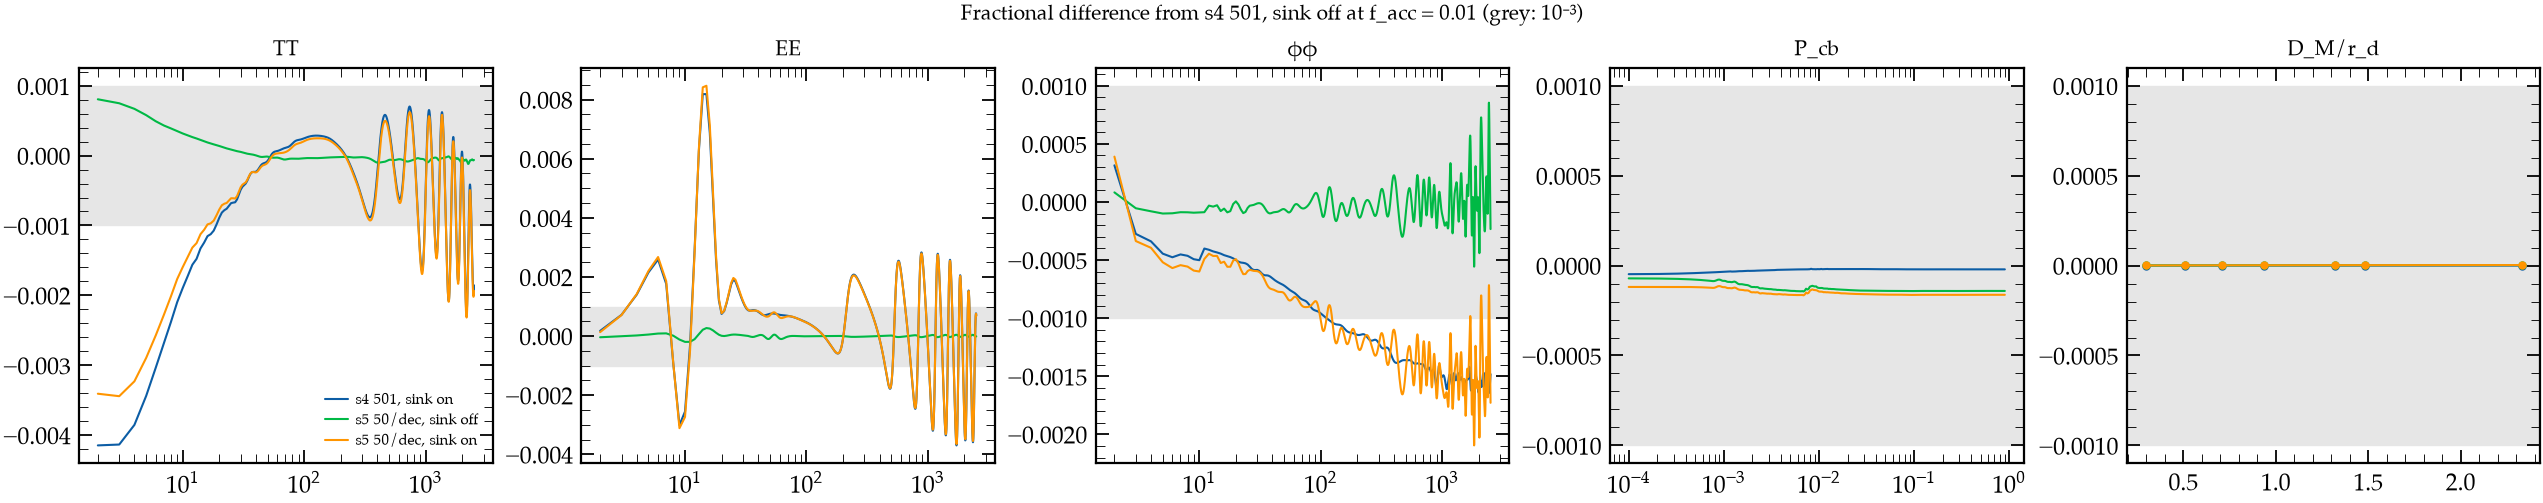

In [3]:
PANELS = [('tt', 'TT', ELL), ('ee', 'EE', ELL), ('pp', 'φφ', ELL), ('pk_cb', 'P_cb', KK), ('DM_rd', 'D_M/r_d', Z_BAO)]
fig, axes = plt.subplots(1, len(PANELS), figsize=(17, 3.4), constrained_layout=True)
for lab in list(CORNERS)[1:]:
    for ax, (key, name, x) in zip(axes, PANELS):
        ax.plot(x, res[(lab, F_SHOW)][key]/res[(REF, F_SHOW)][key] - 1, 'o-' if key == 'DM_rd' else '-',
                lw=1, ms=3, label=lab)
for ax, (key, name, x) in zip(axes, PANELS):
    if key != 'DM_rd':
        ax.set_xscale('log')
    ax.axhspan(-1e-3, 1e-3, color='0.9', zorder=0)
    ax.set_title(name, fontsize=10)
axes[0].legend(fontsize=7)
fig.suptitle('Fractional difference from {} at f_acc = {:g} (grey: 10⁻³)'.format(REF, F_SHOW), fontsize=10)
plt.show()

## 2. Signal and predicted limits

f_lim interpolates log Δχ² in log f between grid points (below the grid, Δχ² ∝ f² is assumed). Ratios
compare each setup with its base on the same f grid.

,f_lim,ratio total,ratio cmb,ratio lens,ratio bao
setup,,,,,
"s4 501, sink off",2.52e-03,1.000,1.000,1.000,1.000
"s4 501, sink on",2.24e-03,0.889,0.889,0.938,1.000
"s5 50/dec, sink off",2.51e-03,0.996,0.996,0.998,1.001
"s5 50/dec, sink on",2.26e-03,0.898,0.897,0.934,1.001
s4 1001,2.53e-03,1.000,1.000,1.004,1.001
s5 25/dec,2.53e-03,1.020,1.020,0.994,0.999
s5 100/dec,2.53e-03,1.019,1.020,1.001,1.000
s5 51 bins,2.54e-03,1.020,1.021,0.999,1.000
s5 101 bins,2.53e-03,1.020,1.020,1.002,1.000


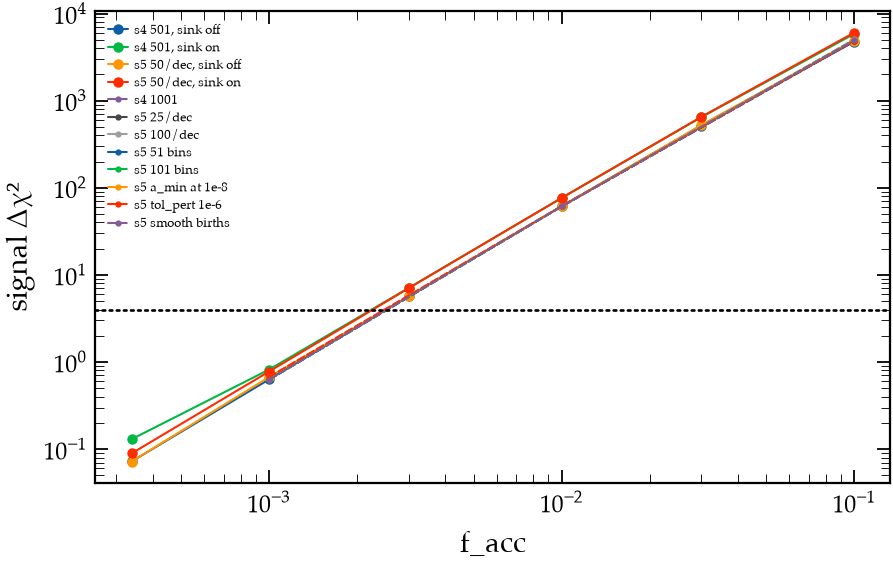

In [4]:
def signal(lab):
    fs = F_CORNER if lab in CORNERS else F_VARIANT
    return [(f, chi2_parts(res[(lab, f)], res[(lab, F_REF)])) for f in fs[1:]]


def f_limit(rows, part='total'):
    f, c = np.array([r[0] for r in rows]), np.array([r[1][part] for r in rows])
    above = np.nonzero(c >= CHI2_LIM)[0]
    if not len(above):
        return np.nan
    i = above[0]
    if i == 0:
        return f[0]*np.sqrt(CHI2_LIM/c[0])
    t = np.log(CHI2_LIM/c[i - 1])/np.log(c[i]/c[i - 1])
    return f[i - 1]*(f[i]/f[i - 1])**t


PARTS = ('total', 'cmb', 'lens', 'bao')
lims = {lab: {p: f_limit(signal(lab), p) for p in PARTS} for lab in SETUPS}
# variants are compared with a base limit computed on their own, coarser f grid
base_lims = {lab: ({p: f_limit([r for r in signal(BASE[lab]) if r[0] in F_VARIANT], p) for p in PARTS}
                   if lab in VARIANTS else lims[BASE[lab]]) for lab in SETUPS}
rows = [{'setup': lab, 'f_lim': lims[lab]['total'],
         **{'ratio ' + p: lims[lab][p]/base_lims[lab][p] for p in PARTS}} for lab in SETUPS]
show(pd.DataFrame(rows).set_index('setup'), {'f_lim': '{:.2e}'}, default='{:.3f}')

fig, ax = plt.subplots(figsize=(6, 3.8), constrained_layout=True)
for lab in SETUPS:
    s = signal(lab)
    ax.loglog([r[0] for r in s], [r[1]['total'] for r in s], 'o-' if lab in CORNERS else '.--', lw=1, ms=4, label=lab)
ax.axhline(CHI2_LIM, color='k', ls=':')
ax.set_xlabel('f_acc')
ax.set_ylabel('signal Δχ²')
ax.legend(fontsize=6)
plt.show()

## 3. Attribution

The 2×2 design measures each effect twice. The shares split the total log shift (strategy 5 + sink
against strategy 4 without) into the sink (measured with strategy 4), the quadrature (measured without
the sink) and the remaining interaction.

In [5]:
s4off, s4on, s5off, s5on = (lims[lab]['total'] for lab in CORNERS)
for name, r in {'sink, with s4 501': s4on/s4off, 'sink, with s5': s5on/s5off, 'quadrature, sink off': s5off/s4off,
                'quadrature, sink on': s5on/s4on, 'both (s5 + sink vs s4)': s5on/s4off}.items():
    print('{:<24s} f_lim × {:.3f}'.format(name, r))
tot, sink, quad = np.log(s5on/s4off), np.log(s4on/s4off), np.log(s5off/s4off)
print('\nshare of the total shift: sink {:.0%}, quadrature {:.0%}, interaction {:.0%}'.format(
    sink/tot, quad/tot, (tot - sink - quad)/tot))

sink, with s4 501        f_lim × 0.889
sink, with s5            f_lim × 0.902
quadrature, sink off     f_lim × 0.996
quadrature, sink on      f_lim × 1.009
both (s5 + sink vs s4)   f_lim × 0.898

share of the total shift: sink 109%, quadrature 4%, interaction -13%
